In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Shape:", df.shape)
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [3]:
print("Missing values total:", df.isna().sum().sum())
print("Baris duplikat:", df.duplicated().sum())
print("EmployeeNumber duplikat:", df['EmployeeNumber'].duplicated().sum())

const_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Kolom konstan:", const_cols)
for c in const_cols:
    print(f"  {c} -> selalu {df[c].unique()[0]}")

print("\nAttrition:")
print(df['Attrition'].value_counts())
print("Rate: %.1f%%" % (100 * df['Attrition'].eq('Yes').mean()))

Missing values total: 0
Baris duplikat: 0
EmployeeNumber duplikat: 0
Kolom konstan: ['EmployeeCount', 'Over18', 'StandardHours']
  EmployeeCount -> selalu 1
  Over18 -> selalu Y
  StandardHours -> selalu 80

Attrition:
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Rate: 16.1%


In [4]:
## Cleaning & Transformasi

In [5]:
# Buang 3 kolom konstan (tidak informatif)
df = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'])

# Target numerik: 1 = resign, 0 = bertahan (dipakai untuk hitung rate & modeling)
df['AttritionFlag'] = (df['Attrition'] == 'Yes').astype(int)

print("Shape sesudah drop:", df.shape)
print(df[['Attrition', 'AttritionFlag']].head())

Shape sesudah drop: (1470, 33)
  Attrition  AttritionFlag
0       Yes              1
1        No              0
2       Yes              1
3        No              0
4        No              0


In [6]:
sat_map = {1: '1-Low', 2: '2-Medium', 3: '3-High', 4: '4-Very High'}
for c in ['EnvironmentSatisfaction', 'JobSatisfaction',
          'RelationshipSatisfaction', 'JobInvolvement']:
    df[c + '_lbl'] = df[c].map(sat_map)

df['WorkLifeBalance_lbl'] = df['WorkLifeBalance'].map(
    {1: '1-Bad', 2: '2-Good', 3: '3-Better', 4: '4-Best'})
df['Education_lbl'] = df['Education'].map(
    {1: '1-Below College', 2: '2-College', 3: '3-Bachelor',
     4: '4-Master', 5: '5-Doctor'})

print(df[['JobSatisfaction', 'JobSatisfaction_lbl',
          'Education', 'Education_lbl']].head())

   JobSatisfaction JobSatisfaction_lbl  Education    Education_lbl
0                4         4-Very High          2        2-College
1                2            2-Medium          1  1-Below College
2                3              3-High          2        2-College
3                3              3-High          4         4-Master
4                2            2-Medium          1  1-Below College


In [7]:
df['AgeBand'] = pd.cut(df['Age'], [17, 24, 34, 44, 54, 100],
    labels=['<25', '25-34', '35-44', '45-54', '55+'])
df['TenureBand'] = pd.cut(df['YearsAtCompany'], [-1, 1, 4, 9, 100],
    labels=['0-1 thn', '2-4 thn', '5-9 thn', '10+ thn'])
df['IncomeBand'] = pd.cut(df['MonthlyIncome'], [0, 3000, 6000, 10000, 100000],
    labels=['<3jt-an', '3-6', '6-10', '10+'])

print(df[['Age','AgeBand','YearsAtCompany','TenureBand']].head())
print("\nShape akhir:", df.shape)

   Age AgeBand  YearsAtCompany TenureBand
0   41   35-44               6    5-9 thn
1   49   45-54              10    10+ thn
2   37   35-44               0    0-1 thn
3   33   25-34               8    5-9 thn
4   27   25-34               2    2-4 thn

Shape akhir: (1470, 42)


In [8]:
import os
os.makedirs("data/processed", exist_ok=True)
df.to_csv("data/processed/hr_attrition_clean.csv", index=False)
print("Tersimpan:", df.shape, "-> data/processed/hr_attrition_clean.csv")

Tersimpan: (1470, 42) -> data/processed/hr_attrition_clean.csv


In [9]:
num = ['Age','MonthlyIncome','DistanceFromHome','TotalWorkingYears',
       'YearsAtCompany','YearsSinceLastPromotion','PercentSalaryHike']
df[num].describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.9,9.1,18.0,30.0,36.0,43.0,60.0
MonthlyIncome,1470.0,6502.9,4708.0,1009.0,2911.0,4919.0,8379.0,19999.0
DistanceFromHome,1470.0,9.2,8.1,1.0,2.0,7.0,14.0,29.0
TotalWorkingYears,1470.0,11.3,7.8,0.0,6.0,10.0,15.0,40.0
YearsAtCompany,1470.0,7.0,6.1,0.0,3.0,5.0,9.0,40.0
YearsSinceLastPromotion,1470.0,2.2,3.2,0.0,0.0,1.0,3.0,15.0
PercentSalaryHike,1470.0,15.2,3.7,11.0,12.0,14.0,18.0,25.0


In [10]:
print("Skew MonthlyIncome:", round(df['MonthlyIncome'].skew(), 2))
print("Skew YearsAtCompany:", round(df['YearsAtCompany'].skew(), 2))

for c in ['Department','Gender','MaritalStatus','OverTime','BusinessTravel']:
    print(f"\n[{c}] (%)")
    print((df[c].value_counts(normalize=True)*100).round(1))

Skew MonthlyIncome: 1.37
Skew YearsAtCompany: 1.76

[Department] (%)
Department
Research & Development    65.4
Sales                     30.3
Human Resources            4.3
Name: proportion, dtype: float64

[Gender] (%)
Gender
Male      60.0
Female    40.0
Name: proportion, dtype: float64

[MaritalStatus] (%)
MaritalStatus
Married     45.8
Single      32.0
Divorced    22.2
Name: proportion, dtype: float64

[OverTime] (%)
OverTime
No     71.7
Yes    28.3
Name: proportion, dtype: float64

[BusinessTravel] (%)
BusinessTravel
Travel_Rarely        71.0
Travel_Frequently    18.8
Non-Travel           10.2
Name: proportion, dtype: float64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
print("Plotting siap")

Plotting siap


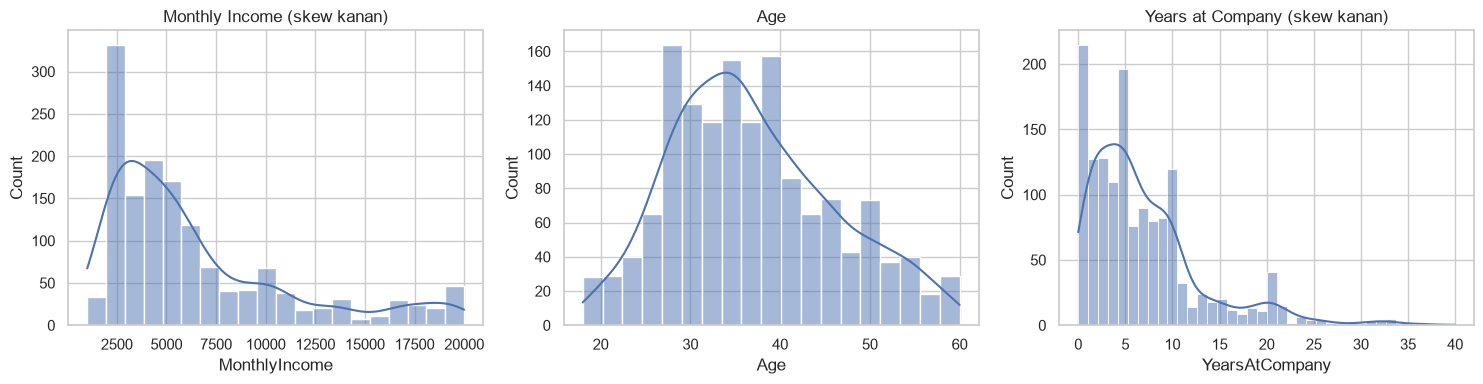

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['MonthlyIncome'], kde=True, ax=axes[0]).set_title('Monthly Income (skew kanan)')
sns.histplot(df['Age'], kde=True, ax=axes[1]).set_title('Age')
sns.histplot(df['YearsAtCompany'], kde=True, ax=axes[2]).set_title('Years at Company (skew kanan)')
plt.tight_layout()
plt.show()

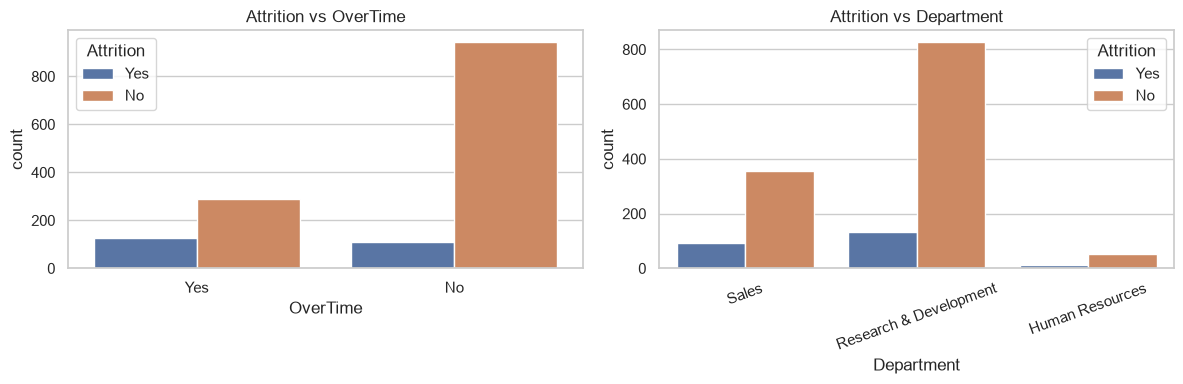

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='OverTime', hue='Attrition', ax=axes[0]).set_title('Attrition vs OverTime')
sns.countplot(data=df, x='Department', hue='Attrition', ax=axes[1]).set_title('Attrition vs Department')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [14]:
BASELINE = df['AttritionFlag'].mean()   # 0.161 = 16,1%

def attrition_by(col, min_n=0):
    g = df.groupby(col, observed=True)['AttritionFlag'].agg(
        headcount='count', n_resign='sum', rate='mean')
    g['rate_%'] = (g['rate'] * 100).round(1)
    g['vs_baseline'] = (g['rate'] / BASELINE).round(2)   # 2.0 = 2x lipat baseline
    g = g.drop(columns='rate').sort_values('rate_%', ascending=False)
    return g[g['headcount'] >= min_n]

print(f"Baseline attrition: {BASELINE*100:.1f}%")

Baseline attrition: 16.1%


In [15]:
print("=== Per Department ===")
display(attrition_by('Department'))

print("=== Per Job Role ===")
display(attrition_by('JobRole'))

print("=== Per Job Level ===")
display(attrition_by('JobLevel'))

=== Per Department ===


,headcount,n_resign,rate_%,vs_baseline
Department,,,,
Sales,446,92,20.6,1.28
Human Resources,63,12,19.0,1.18
Research & Development,961,133,13.8,0.86


=== Per Job Role ===


,headcount,n_resign,rate_%,vs_baseline
JobRole,,,,
Sales Representative,83,33,39.8,2.47
Laboratory Technician,259,62,23.9,1.48
Human Resources,52,12,23.1,1.43
Sales Executive,326,57,17.5,1.08
Research Scientist,292,47,16.1,1.00
Healthcare Representative,131,9,6.9,0.43
Manufacturing Director,145,10,6.9,0.43
Manager,102,5,4.9,0.30
Research Director,80,2,2.5,0.16


=== Per Job Level ===


,headcount,n_resign,rate_%,vs_baseline
JobLevel,,,,
1,543,143,26.3,1.63
3,218,32,14.7,0.91
2,534,52,9.7,0.60
5,69,5,7.2,0.45
4,106,5,4.7,0.29


In [16]:
for col in ['OverTime', 'BusinessTravel', 'TenureBand',
            'JobSatisfaction_lbl', 'WorkLifeBalance_lbl', 'StockOptionLevel']:
    print(f"\n=== {col} ===")
    display(attrition_by(col))


=== OverTime ===


,headcount,n_resign,rate_%,vs_baseline
OverTime,,,,
Yes,416,127,30.5,1.89
No,1054,110,10.4,0.65



=== BusinessTravel ===


,headcount,n_resign,rate_%,vs_baseline
BusinessTravel,,,,
Travel_Frequently,277,69,24.9,1.55
Travel_Rarely,1043,156,15.0,0.93
Non-Travel,150,12,8.0,0.50



=== TenureBand ===


...

,headcount,n_resign,rate_%,vs_baseline
JobSatisfaction_lbl,,,,
1-Low,289,66,22.8,1.42
3-High,442,73,16.5,1.02
2-Medium,280,46,16.4,1.02
4-Very High,459,52,11.3,0.70



=== WorkLifeBalance_lbl ===


,headcount,n_resign,rate_%,vs_baseline
WorkLifeBalance_lbl,,,,
1-Bad,80,25,31.2,1.94
4-Best,153,27,17.6,1.09
2-Good,344,58,16.9,1.05
3-Better,893,127,14.2,0.88



=== StockOptionLevel ===


,headcount,n_resign,rate_%,vs_baseline
StockOptionLevel,,,,
0,631,154,24.4,1.51
3,85,15,17.6,1.09
1,596,56,9.4,0.58
2,158,12,7.6,0.47


In [17]:
num_drivers = ['Age','MonthlyIncome','DistanceFromHome','PercentSalaryHike',
               'YearsSinceLastPromotion','TotalWorkingYears','YearsWithCurrManager']

comp = df.groupby('Attrition')[num_drivers].mean().round(1).T
comp['selisih_%'] = ((comp['Yes'] - comp['No']) / comp['No'] * 100).round(1)
comp

Attrition,No,Yes,selisih_%
Age,37.6,33.6,-10.6
MonthlyIncome,6832.7,4787.1,-29.9
DistanceFromHome,8.9,10.6,19.1
PercentSalaryHike,15.2,15.1,-0.7
YearsSinceLastPromotion,2.2,1.9,-13.6
TotalWorkingYears,11.9,8.2,-31.1
YearsWithCurrManager,4.4,2.9,-34.1


In [18]:
print("=== Median gaji per Gender (MENTAH, belum dikontrol) ===")
print(df.groupby('Gender')['MonthlyIncome'].median())

print("\n=== Median gaji per Job Level x Gender (DIKONTROL level) ===")
pivot = df.groupby(['JobLevel','Gender'])['MonthlyIncome'].median().unstack()
pivot['gap_F_vs_M_%'] = ((pivot['Female'] - pivot['Male']) / pivot['Male'] * 100).round(1)
display(pivot)

=== Median gaji per Gender (MENTAH, belum dikontrol) ===
Gender
Female    5081.5
Male      4837.5
Name: MonthlyIncome, dtype: float64

=== Median gaji per Job Level x Gender (DIKONTROL level) ===


Gender,Female,Male,gap_F_vs_M_%
JobLevel,,,
1,2659.0,2678.5,-0.7
2,5247.5,5383.5,-2.5
3,10052.0,9854.0,2.0
4,16064.0,16328.0,-1.6
5,19071.5,19246.0,-0.9


In [20]:
#Logistic Regression

In [21]:
try:
    import statsmodels.api as sm
    print("statsmodels OK")
except ImportError:
    print("statsmodels BELUM ada -> buka Anaconda Prompt KEDUA, jalankan: conda install statsmodels")

statsmodels OK


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Fitur numerik + ordinal (skala 1-4 diperlakukan numerik = asumsi efek linear)
numeric_feats = ['Age','DistanceFromHome','MonthlyIncome','NumCompaniesWorked',
    'PercentSalaryHike','TotalWorkingYears','TrainingTimesLastYear','YearsAtCompany',
    'YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager',
    'Education','EnvironmentSatisfaction','JobInvolvement','JobLevel','JobSatisfaction',
    'RelationshipSatisfaction','StockOptionLevel','WorkLifeBalance']

# Fitur kategorikal (akan di-one-hot)
cat_feats = ['BusinessTravel','Department','EducationField','Gender',
             'JobRole','MaritalStatus','OverTime']

y = df['AttritionFlag']
X_num = df[numeric_feats]
X_cat = pd.get_dummies(df[cat_feats], drop_first=True)   # one-hot, buang 1 kategori referensi

X = pd.concat([X_num, X_cat], axis=1)
print("Jumlah fitur akhir:", X.shape[1])
print("Contoh kolom kategorikal hasil encoding:", list(X_cat.columns[:5]))

Jumlah fitur akhir: 40
Contoh kolom kategorikal hasil encoding: ['BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences']


In [23]:
# Standardkan HANYA kolom numerik (agar odds ratio antar-fitur bisa dibandingkan: per 1 SD)
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_feats] = scaler.fit_transform(X[numeric_feats])

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Attrition rate train:", round(y_train.mean(),3), "| test:", round(y_test.mean(),3))

Train: (1102, 40) | Test: (368, 40)
Attrition rate train: 0.162 | test: 0.16


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score)

# class_weight='balanced' -> WAJIB karena target timpang (16%)
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))

=== Confusion Matrix ===
[[254  55]
 [ 19  40]]

=== Classification Report ===
              precision    recall  f1-score   support

           0      0.930     0.822     0.873       309
           1      0.421     0.678     0.519        59

    accuracy                          0.799       368
   macro avg      0.676     0.750     0.696       368
weighted avg      0.849     0.799     0.816       368

ROC-AUC: 0.819


In [25]:
import numpy as np

coefs = pd.DataFrame({'feature': X_train.columns, 'coef': model.coef_[0]})
coefs['odds_ratio'] = np.exp(coefs['coef'])
coefs = coefs.sort_values('odds_ratio', ascending=False)

print("=== TOP faktor MENAIKKAN risiko resign (OR > 1) ===")
display(coefs.head(10).round(3))

print("=== TOP faktor MENURUNKAN risiko / protektif (OR < 1) ===")
display(coefs.tail(10).round(3).iloc[::-1])

=== TOP faktor MENAIKKAN risiko resign (OR > 1) ===


,feature,coef,odds_ratio
19,BusinessTravel_Travel_Frequently,1.612,5.015
39,OverTime_Yes,1.611,5.007
30,JobRole_Laboratory Technician,1.557,4.743
36,JobRole_Sales Representative,1.211,3.357
38,MaritalStatus_Single,0.931,2.536
20,BusinessTravel_Travel_Rarely,0.853,2.346
29,JobRole_Human Resources,0.766,2.151
14,JobLevel,0.606,1.833
9,YearsSinceLastPromotion,0.554,1.741
3,NumCompaniesWorked,0.463,1.589


=== TOP faktor MENURUNKAN risiko / protektif (OR < 1) ===


,feature,coef,odds_ratio
26,EducationField_Other,-0.881,0.414
33,JobRole_Research Director,-0.811,0.444
23,EducationField_Life Sciences,-0.535,0.586
5,TotalWorkingYears,-0.488,0.614
21,Department_Research & Development,-0.472,0.624
10,YearsWithCurrManager,-0.452,0.636
25,EducationField_Medical,-0.435,0.647
2,MonthlyIncome,-0.409,0.664
12,EnvironmentSatisfaction,-0.405,0.667
15,JobSatisfaction,-0.382,0.682


In [26]:
import statsmodels.api as sm
X_sm = sm.add_constant(X_train.astype(float))
logit = sm.Logit(y_train, X_sm).fit(disp=0)
res = pd.DataFrame({'coef': logit.params, 'p_value': logit.pvalues})
res['odds_ratio'] = np.exp(res['coef'])
res = res[res['p_value'] < 0.05].sort_values('odds_ratio', ascending=False)
print("Faktor signifikan secara statistik (p < 0,05):")
display(res.round(3))

Faktor signifikan secara statistik (p < 0,05):


D:\Apps\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,coef,p_value,odds_ratio
JobRole_Sales Representative,2.872,0.024,17.678
JobRole_Laboratory Technician,2.158,0.001,8.653
BusinessTravel_Travel_Frequently,2.060,0.000,7.847
OverTime_Yes,1.980,0.000,7.244
BusinessTravel_Travel_Rarely,1.081,0.016,2.947
MaritalStatus_Single,0.904,0.026,2.469
YearsSinceLastPromotion,0.618,0.000,1.856
NumCompaniesWorked,0.487,0.000,1.627
DistanceFromHome,0.415,0.000,1.514
TrainingTimesLastYear,-0.225,0.044,0.799


In [27]:
import joblib

# Skor risiko untuk SEMUA karyawan (probabilitas resign 0-1)
df['AttritionRisk'] = model.predict_proba(X_scaled)[:, 1]
df['RiskTier'] = pd.cut(df['AttritionRisk'], [0, 0.3, 0.6, 1.0],
                        labels=['Low', 'Medium', 'High'])

# Simpan dataset ber-skor + model
df.to_csv("data/processed/hr_attrition_scored.csv", index=False)
joblib.dump(model, "outputs/logit_model.pkl") if __import__('os').path.exists("outputs") else __import__('os').makedirs("outputs") or joblib.dump(model, "outputs/logit_model.pkl")

print(df['RiskTier'].value_counts())
print("Tersimpan: hr_attrition_scored.csv + logit_model.pkl")

RiskTier
Low       754
Medium    381
High      335
Name: count, dtype: int64
Tersimpan: hr_attrition_scored.csv + logit_model.pkl


In [28]:
# Perbaiki label ke English + tambah kolom urutan
df['TenureBand'] = df['TenureBand'].cat.rename_categories(
    ['0-1 Yrs', '2-4 Yrs', '5-9 Yrs', '10+ Yrs'])

# Kolom urutan (agar BI tool tidak mengurutkan secara abjad)
order_map = {'0-1 Yrs': 1, '2-4 Yrs': 2, '5-9 Yrs': 3, '10+ Yrs': 4}
df['TenureOrder'] = df['TenureBand'].map(order_map)

df.to_csv("data/processed/hr_attrition_scored.csv", index=False)
print(df[['TenureBand','TenureOrder']].drop_duplicates().sort_values('TenureOrder'))

  TenureBand TenureOrder
2    0-1 Yrs           1
4    2-4 Yrs           2
0    5-9 Yrs           3
1    10+ Yrs           4
